In [1]:
import cv2
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
import os
import pandas as pd
import matplotlib.pyplot as plt
import random
from PIL import Image
from matplotlib.gridspec import GridSpec
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, Model
from itertools import cycle
from sklearn.metrics import roc_curve, auc

In [2]:
data = "E:\\DATASET\\"
file_list = os.listdir(data)
print(file_list)

['Normal', 'Sick']


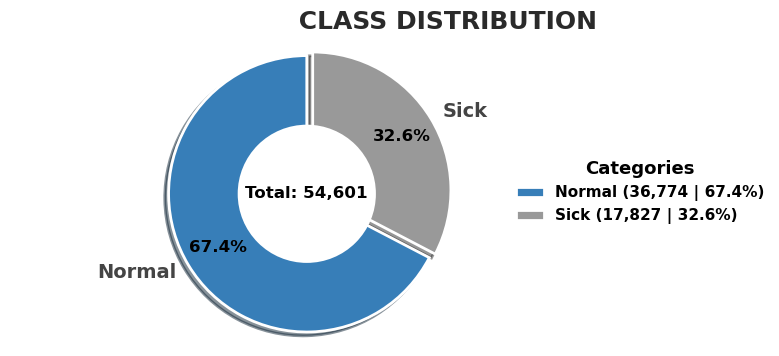

In [5]:
image_counts = {}
for folder_name in os.listdir(data):
    folder_path = os.path.join(data, folder_name)
    if os.path.isdir(folder_path):
        num_images = len([file for file in os.listdir(folder_path) if file.lower().endswith('jpg')])
        image_counts[folder_name] = num_images
image_counts = dict(sorted(image_counts.items()))

class_names = list(image_counts.keys())
counts = list(image_counts.values())
colors = plt.cm.Set1(np.linspace(0.2, 0.9, len(class_names)))
counts_array = np.array(counts)
total = sum(counts_array)
percentages = counts_array / total * 100
explode = [0.05 if c == min(counts_array) else 0 for c in counts_array]
pct_distance_value = 0.75
wedges, texts, autotexts = plt.pie(counts_array, 
                                   labels=class_names, 
                                   autopct=lambda p: f'{p:.1f}%' if p > 5 else '',
                                   startangle=90,
                                   colors=colors,
                                   explode=explode,
                                   wedgeprops={'width': 0.6, 'edgecolor': 'white', 'linewidth': 2},
                                   shadow=True,
                                   textprops={'fontsize': 11, 'fontweight': 'semibold', 'color': '#333333'},
                                   pctdistance=pct_distance_value)

centre_circle = plt.Circle((0, 0), 0.5, color='white', fc='white', linewidth=0)
plt.gca().add_artist(centre_circle)

plt.setp(texts, size=14, weight='bold', color='#444444')
plt.setp(autotexts, size=12, weight='bold', color='black')

plt.annotate(f'Total: {total:,}', 
             xy=(0, 0), 
             fontsize=12,
             ha='center',
             va='center',
             weight='bold')

legend_labels = [f'{l} ({c:,} | {s:.1f}%)' for l, c, s in zip(class_names, counts_array, percentages)]
legend = plt.legend(wedges, legend_labels,
                    title="Categories",
                    loc="center left",
                    bbox_to_anchor=(1, 0, 0.3, 1),
                    frameon=False)

legend.get_title().set_fontsize(13)
legend.get_title().set_fontweight('bold')

for label in legend.get_texts():
    label.set_fontsize(11)
    label.set_fontweight('bold')
plt.suptitle('                                 CLASS DISTRIBUTION', y=0.95, fontsize=18, weight='bold', color='#2a2a2a')
plt.axis('equal')

plt.gcf().set_size_inches(5,4)

plt.show()

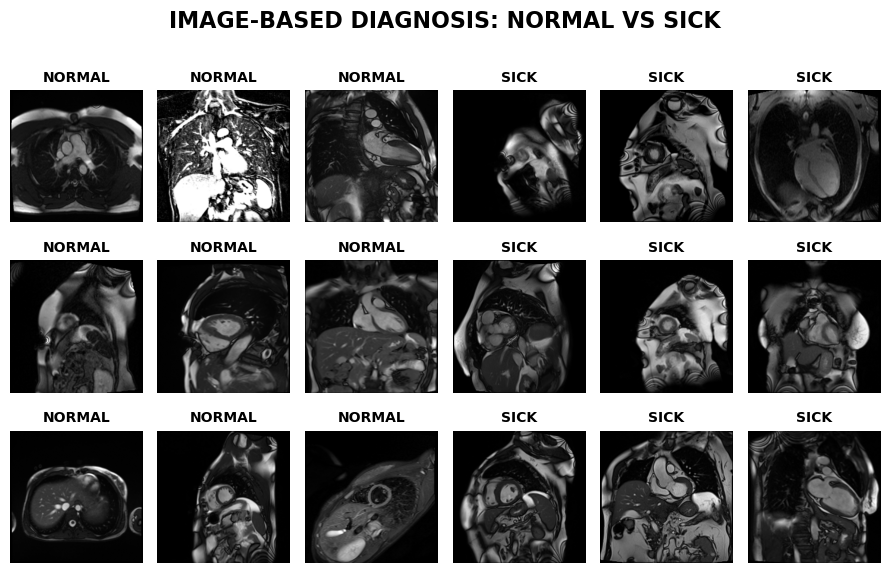

In [6]:
normal_path = os.path.join(data, 'Normal')
sick_path = os.path.join(data, 'Sick')

def get_random_images(folder_path, num_images=9):
    all_images = [img for img in os.listdir(folder_path) if img.lower().endswith('.jpg')]
    random_images = random.sample(all_images, min(num_images, len(all_images)))
    return [os.path.join(folder_path, img) for img in random_images]

normal_images = get_random_images(normal_path)
sick_images = get_random_images(sick_path)

fig, axs = plt.subplots(3, 6, figsize=(9, 6))
fig.suptitle('IMAGE-BASED DIAGNOSIS: NORMAL VS SICK', fontsize=16, fontweight='bold', color='BLACK')

resize_shape = (512,512)  

for i, img_path in enumerate(normal_images):
    img = Image.open(img_path).resize(resize_shape)
    ax = axs[i // 3, i % 3]  
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title('NORMAL', fontsize=10, fontweight='bold')

for i, img_path in enumerate(sick_images):
    img = Image.open(img_path).resize(resize_shape)
    ax = axs[i // 3, i % 3 + 3] 
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title('SICK', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show() 

C:\Users\user\AppData\Local\Temp\ipykernel_10860\810998800.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


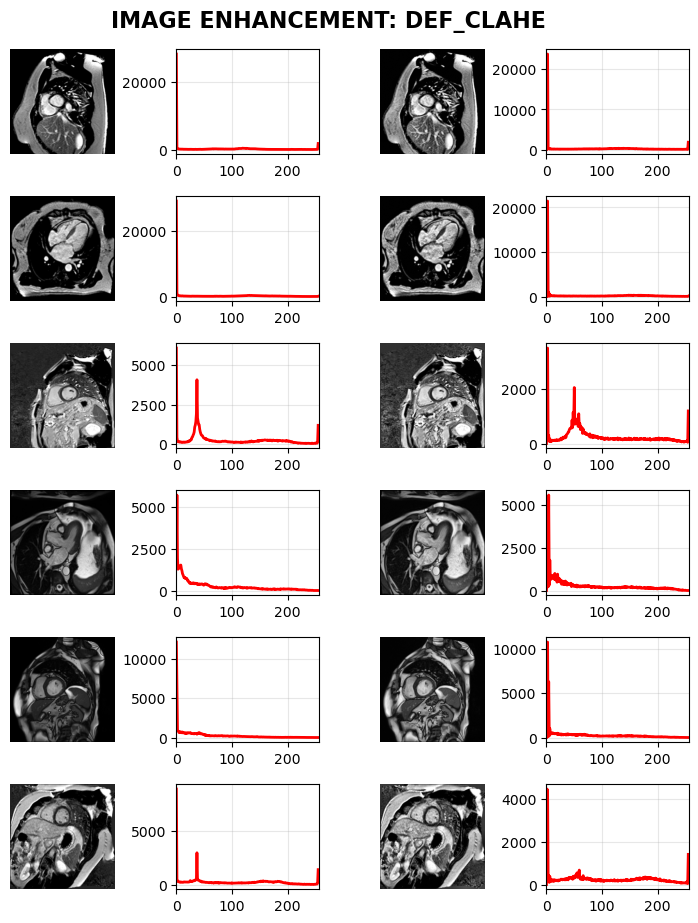

In [8]:
image_files = [f for f in os.listdir(DATA_PATH) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))]
image_files = image_files[:6] 

fig = plt.figure(figsize=(9,10))
fig.suptitle('IMAGE ENHANCEMENT: DEF_CLAHE', fontsize=16, y=0.99, fontweight='bold')

gs = GridSpec(6, 4, figure=fig, width_ratios=[1, 1, 1, 1], 
              height_ratios=[1, 1, 1, 1, 1, 1], 
              wspace=0.3, hspace=0.4)

resize_dim = (256, 256)

for i, img_file in enumerate(image_files):
    img_path = os.path.join(DATA_PATH, img_file)
    img = cv2.imread(img_path)
    
    img = cv2.resize(img, resize_dim)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    edges = cv2.Canny(img_gray, 100, 200)
    edge_mask = (edges > 0).astype(np.uint8)
    clahe_img = clahe.apply(img_gray)
    
    enhanced_img = img_gray.copy()
    enhanced_img = cv2.addWeighted(clahe_img, 0.7, img_gray, 0.3, 0)
    enhanced_img[edge_mask == 1] = clahe_img[edge_mask == 1]
    ax1 = fig.add_subplot(gs[i, 0])
    ax1.imshow(img_rgb)
    ax1.axis('off')
    
    ax2 = fig.add_subplot(gs[i, 1])
    hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
    ax2.plot(hist, linewidth=2,color='red')
    ax2.set_xlim([0, 256])
    ax2.grid(alpha=0.3)
    
    ax3 = fig.add_subplot(gs[i, 2])
    ax3.imshow(enhanced_img, cmap='gray')
    ax3.axis('off')
    
    ax4 = fig.add_subplot(gs[i, 3])
    hist_enhanced = cv2.calcHist([enhanced_img], [0], None, [256], [0, 256])
    ax4.plot(hist_enhanced,color='red', linewidth=2)
    ax4.set_xlim([0, 256])
    ax4.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_10860\204343774.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


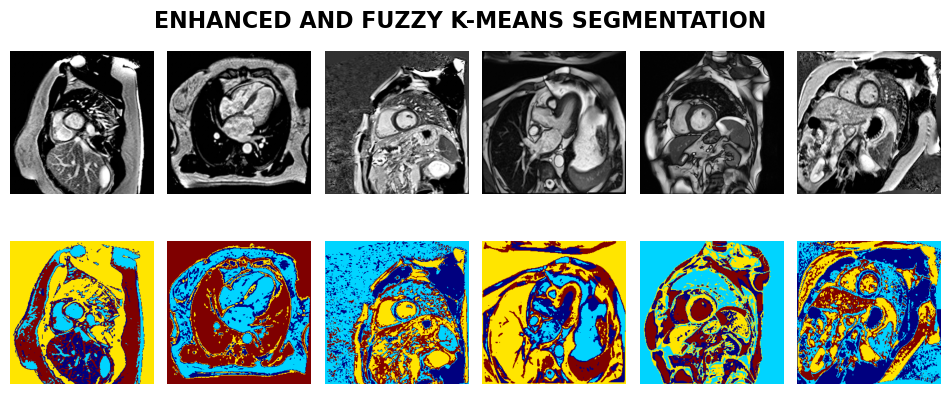

In [14]:
def fuzzy_kmeans_segmentation(image_gray, n_clusters=4, m=2):
    img_flat = image_gray.reshape((-1, 1)).astype(np.float32) / 255.0
    N = img_flat.shape[0]

    U = np.random.dirichlet(np.ones(n_clusters), size=N)

    for _ in range(10): 
        um = U ** m
        centers = (um.T @ img_flat) / np.sum(um.T, axis=1, keepdims=True)

        dist = np.zeros((N, n_clusters))
        for k in range(n_clusters):
            dist[:, k] = np.abs(img_flat.squeeze() - centers[k])

        dist = np.fmax(dist, 1e-10) 

        for k in range(n_clusters):
            denom = np.sum((dist[:, k][:, None] / dist) ** (2 / (m - 1)), axis=1)
            U[:, k] = 1 / denom

    labels = np.argmax(U, axis=1)
    segmented = (labels.reshape(image_gray.shape) * int(255 / (n_clusters - 1))).astype(np.uint8)
    return segmented

fig = plt.figure(figsize=(12,4)) 
fig.suptitle('ENHANCED AND FUZZY K-MEANS SEGMENTATION', fontsize=16, y=1.05, fontweight='bold')
gs = GridSpec(2, 6, figure=fig, wspace=0.1, hspace=0.3)
resize_dim = (256, 256)

for i, img_file in enumerate(image_files):
    img_path = os.path.join(DATA_PATH, img_file)
    img = cv2.imread(img_path)
    img = cv2.resize(img, resize_dim)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    edges = cv2.Canny(img_gray, 100, 200)
    edge_mask = (edges > 0).astype(np.uint8)
    clahe_img = clahe.apply(img_gray)
    enhanced_img = cv2.addWeighted(clahe_img, 0.7, img_gray, 0.3, 0)
    enhanced_img[edge_mask == 1] = clahe_img[edge_mask == 1]

    segmented_img = fuzzy_kmeans_segmentation(enhanced_img)

    ax1 = fig.add_subplot(gs[0, i])  
    ax1.imshow(enhanced_img, cmap='gray')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[1, i])
    ax2.imshow(segmented_img, cmap='jet')
    ax2.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [15]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 123

train_val = tf.keras.preprocessing.image_dataset_from_directory(
    data,
    seed=SEED,
    shuffle=True,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.30,
    subset="training"
)

test = tf.keras.preprocessing.image_dataset_from_directory(
    data,
    seed=SEED,
    shuffle=True,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.30,
    subset="validation"
)

train_val_batches = tf.data.experimental.cardinality(train_val).numpy()

val_batches = int(train_val_batches * 0.20)

validation = train_val.take(val_batches)
train = train_val.skip(val_batches)


print("Training batches:", tf.data.experimental.cardinality(train).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation).numpy())
print("Test batches:", tf.data.experimental.cardinality(test).numpy())

print("\nClass names:")
print(train_val.class_names)

Found 54601 files belonging to 2 classes.
Using 38221 files for training.
Found 54601 files belonging to 2 classes.
Using 16380 files for validation.
Training batches: 956
Validation batches: 239
Test batches: 512

Class names:
['Normal', 'Sick']


In [7]:
class SEBlock(layers.Layer):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.global_pool = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(channels // reduction, activation='relu')
        self.fc2 = layers.Dense(channels, activation='sigmoid')
        self.reshape = layers.Reshape((1, 1, channels))

    def call(self, inputs):
        x = self.global_pool(inputs)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.reshape(x)
        return inputs * x


class ResSEBlock(layers.Layer):
    def __init__(self, channels, reduction=16):
        super(ResSEBlock, self).__init__()
        self.conv1 = layers.Conv2D(channels, 3, padding='same', activation='relu')
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(channels, 3, padding='same')
        self.bn2 = layers.BatchNormalization()
        self.se = SEBlock(channels, reduction)

    def call(self, inputs, training=False):
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        x = self.se(x)
        return layers.Add()([inputs, x])


class DeiTResSENet(Model):
    def __init__(self, num_classes, img_size=224, patch_size=15, d_model=192,
                 num_heads=3, num_layers=12, mlp_dim=768, dropout=0.1):
        super(DeiTResSENet, self).__init__()
        num_patches = (img_size // patch_size) ** 2

        self.patch_embed = layers.Conv2D(d_model, patch_size, strides=patch_size)
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, d_model),
            initializer='zeros',
            trainable=True
        )
        self.dist_token = self.add_weight(
            name="dist_token",
            shape=(1, 1, d_model),
            initializer='zeros',
            trainable=True
        )
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=(1, num_patches + 2, d_model),
            initializer='zeros',
            trainable=True
        )
        self.pos_drop = layers.Dropout(dropout)

        self.encoder_layers = [
            layers.TransformerEncoderLayer(d_model, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ]

        self.resse_blocks = [
            ResSEBlock(d_model) for _ in range(2)
        ]
        self.global_pool = layers.GlobalAveragePooling2D()
        self.classifier = layers.Dense(num_classes, activation='softmax')

    def call(self, inputs, training=False):
        x = self.patch_embed(inputs)
        B = tf.shape(x)[0]
        x = tf.reshape(x, (B, -1, x.shape[-1]))

        cls_tokens = tf.tile(self.cls_token, [B, 1, 1])
        dist_tokens = tf.tile(self.dist_token, [B, 1, 1])
        x = tf.concat([cls_tokens, dist_tokens, x], axis=1)
        x = x + self.pos_embed
        x = self.pos_drop(x, training=training)

        for layer in self.encoder_layers:
            x = layer(x, training=training)

        cls_out = x[:, 0, :]
        cls_spatial = tf.reshape(cls_out, (B, 1, 1, -1))

        for block in self.resse_blocks:
            cls_spatial = block(cls_spatial, training=training)

        cls_out = tf.reshape(cls_spatial, (B, -1))
        return self.classifier(cls_out)


learning_rate = 1e-4
dropout = 0.1
num_layers = 12
d_model = 192
patch_size = 15
num_heads = 3
mlp_dim = d_model * 4
num_classes = len(train_val.class_names)

model = DeiTResSENet(
    num_classes=num_classes,
    img_size=224,
    patch_size=patch_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    mlp_dim=mlp_dim,
    dropout=dropout
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train,
    validation_data=validation,
    epochs=10,
    verbose=1
)

test_loss, test_acc = model.evaluate(test)

Epoch 1/10


C:\Users\user\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\nn.py:678: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1195/1195 ━━━━━━━━━━━━━━━━━━━━ 448s 373ms/step - accuracy: 0.7109 - loss: 0.5604 - val_accuracy: 0.9203 - val_loss: 0.2180
Epoch 2/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 106s 89ms/step - accuracy: 0.9203 - loss: 0.2163 - val_accuracy: 0.9589 - val_loss: 0.1106
Epoch 3/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 108s 91ms/step - accuracy: 0.9577 - loss: 0.1164 - val_accuracy: 0.9697 - val_loss: 0.0782
Epoch 4/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 105s 87ms/step - accuracy: 0.9716 - loss: 0.0751 - val_accuracy: 0.9764 - val_loss: 0.0630
Epoch 5/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 115s 96ms/step - accuracy: 0.9812 - loss: 0.0507 - val_accuracy: 0.9759 - val_loss: 0.0659
Epoch 6/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 103s 86ms/step - accuracy: 0.9865 - loss: 0.0380 - val_accuracy: 0.9845 - val_loss: 0.0488
Epoch 7/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 102s 85ms/step - accuracy: 0.9888 - loss: 0.0320 - val_accuracy: 0.9850 - val_loss: 0.0523
Epoch 8/10
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 102s 86ms/step - accuracy: 0.9919 - l

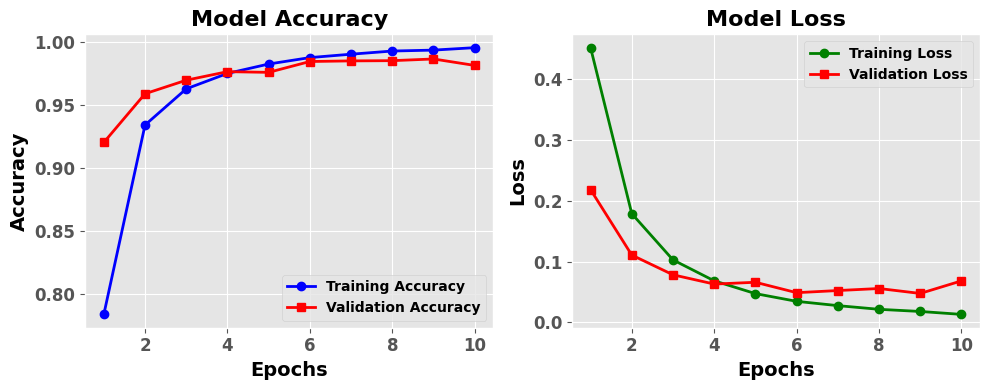

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs_range, acc, label='Training Accuracy', marker='o', markersize=6, color='blue', linestyle='-', linewidth=2)
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy', marker='s', markersize=6, color='red', linestyle='-', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=16, weight='bold', color='black')
axes[0].set_xlabel('Epochs', fontsize=14, weight='bold', color='black')
axes[0].set_ylabel('Accuracy', fontsize=14, weight='bold', color='black')
axes[0].tick_params(axis='both', labelsize=12)
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontweight('bold')
axes[0].legend(prop={'weight': 'bold', 'size': 10})

axes[1].plot(epochs_range, loss, label='Training Loss', marker='o', markersize=6, color='green', linestyle='-', linewidth=2)
axes[1].plot(epochs_range, val_loss, label='Validation Loss', marker='s', markersize=6, color='red', linestyle='-', linewidth=2)
axes[1].set_title('Model Loss', fontsize=16, weight='bold', color='black')
axes[1].set_xlabel('Epochs', fontsize=14, weight='bold', color='black')
axes[1].set_ylabel('Loss', fontsize=14, weight='bold', color='black')
axes[1].tick_params(axis='both', labelsize=12)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontweight('bold')
axes[1].legend(prop={'weight': 'bold', 'size': 10})

plt.tight_layout()
plt.show()

512/512 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99     11110
        Sick       0.97      0.97      0.97      5270

    accuracy                           0.98     16380
   macro avg       0.98      0.98      0.98     16380
weighted avg       0.98      0.98      0.98     16380



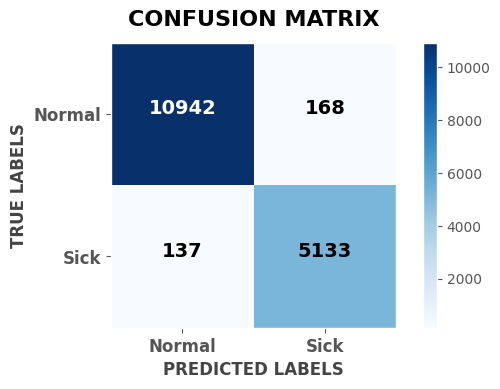

In [54]:
validation_images = []
validation_labels = []
for images, labels in validation:
    validation_images.append(images.numpy())
    validation_labels.append(labels.numpy())
validation_images = np.concatenate(validation_images)
validation_labels = np.concatenate(validation_labels)

predictions = model.predict(validation_images)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(validation_labels, predicted_labels)
print("Classification Report:")
print(classification_report(validation_labels, predicted_labels, target_names=class_names))

plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, fontweight='bold', fontsize=12) 
plt.yticks(tick_marks, class_names, fontweight='bold', fontsize=12)  

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontweight='bold', fontsize=14)  

plt.grid(False)
plt.title('CONFUSION MATRIX', fontsize=16, fontweight='bold', color='black', y=1.03)
plt.xlabel('PREDICTED LABELS', fontsize=12, fontweight='bold', color='#444444')
plt.ylabel('TRUE LABELS', fontsize=12, fontweight='bold', color='#444444')
plt.tight_layout()
plt.show()

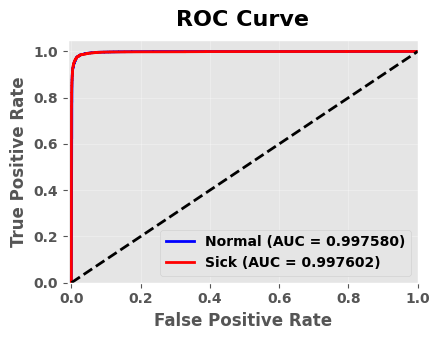

In [55]:
def plot_multiclass_roc(y_true, y_score, classes):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve((y_true == i).astype(int), y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    fpr["micro"], tpr["micro"], _ = roc_curve(np.eye(len(classes))[y_true].ravel(), 
                                               y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(4.5,3.5))
    colors = cycle(['blue','red'])
    
    for i, color in zip(range(len(classes)), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='{0} (AUC = {1:f})'.format(classes[i], roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel('False Positive Rate', fontsize=12, fontweight="bold")
    plt.ylabel('True Positive Rate', fontsize=12, fontweight="bold")

    plt.title('ROC Curve', fontsize=16, fontweight="bold", pad=10)

    plt.legend(loc="lower right", fontsize=14, prop={'weight': 'bold'})

    plt.tick_params(axis='both', labelsize=10)
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curves.png', bbox_inches='tight')
    plt.show()

plot_multiclass_roc(validation_labels, predictions, class_names)

In [56]:
import numpy as np
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, cohen_kappa_score)

cm = confusion_matrix(validation_labels, predicted_labels)
tn, fp, fn, tp = cm.ravel()

precision = precision_score(validation_labels, predicted_labels)
recall = recall_score(validation_labels, predicted_labels)

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

f2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) > 0 else 0.0

youden_j = recall + specificity - 1
metrics = {
    'Accuracy': accuracy_score(validation_labels, predicted_labels),
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'Specificity': specificity,
    'F1 Score': f1_score(validation_labels, predicted_labels),
    'F2 Score': f2_score,
    "Cohen's Kappa": cohen_kappa_score(validation_labels, predicted_labels),
    "Youden's J": youden_j  
}

print("\n" + "="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print(f"{'Metric':<30} {'Value':>15}")
print("-"*47)
for name, value in metrics.items():
    print(f"{name:<30} {value:>15.2%}")
print("="*60)


MODEL EVALUATION METRICS
Metric                                   Value
-----------------------------------------------
Accuracy                                98.14%
Precision                               96.83%
Recall (Sensitivity)                    97.40%
Specificity                             98.49%
F1 Score                                97.11%
F2 Score                                97.29%
Cohen's Kappa                           95.74%
Youden's J                              95.89%


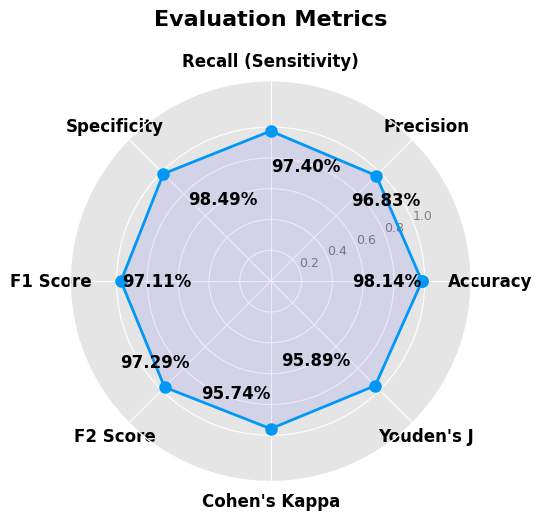

In [57]:
def plot_radar_metrics(metrics_dict):
    plt.figure(figsize=(5.5,5.5))
    categories = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  
    values += values[:1]
    ax = plt.subplot(111, polar=True)

    plt.xticks(angles[:-1], categories, color='BLACK', size=12,fontweight='bold')
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=9)
    plt.ylim(0, 1.3)
    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#0197f6', marker='o', markersize=8)
    ax.fill(angles, values, color='blue', alpha=0.08)
    
    for i in range(N):
        angle_rad = angles[i]
        value = values[i]
        ha = 'center'
        if angle_rad == 0 or angle_rad == np.pi:
            ha = 'center'
        elif 0 < angle_rad < np.pi:
            ha = 'left'
        else:
            ha = 'right'
        
        ax.text(angle_rad, value -0.23, f'{value:.2%}',
                ha=ha, va='center', fontsize=12, color='black', weight='bold')

    plt.title('Evaluation Metrics', size=16, color='black', fontweight='bold', pad=40)
    
    plt.tight_layout()
    plt.show()

plot_radar_metrics(metrics)

In [28]:
class SEBlock(layers.Layer):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.global_pool = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(channels // reduction, activation='relu')
        self.fc2 = layers.Dense(channels, activation='sigmoid')
        self.reshape = layers.Reshape((1, 1, channels))

    def call(self, inputs):
        x = self.global_pool(inputs)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.reshape(x)
        return inputs * x  

class ResSEBlock(layers.Layer):
    def __init__(self, channels, reduction=16):
        super(ResSEBlock, self).__init__()
        self.conv1 = layers.Conv2D(channels, 3, padding='same', activation='relu')
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(channels, 3, padding='same')
        self.bn2 = layers.BatchNormalization()
        self.se = SEBlock(channels, reduction)

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.se(x)
        return layers.Add()([inputs, x])  

class DeiTResSENet(Model):
    def __init__(self, num_classes, img_size=224, patch_size=15, d_model=192,
                 num_heads=3, num_layers=12, mlp_dim=768, dropout=0.1):
        super(DeiTResSENet, self).__init__()
        num_patches = (img_size // patch_size) ** 2

        self.patch_embed = layers.Conv2D(d_model, patch_size, strides=patch_size)
        self.cls_token = self.add_weight(shape=(1, 1, d_model), initializer='zeros', trainable=True)
        self.dist_token = self.add_weight(shape=(1, 1, d_model), initializer='zeros', trainable=True)
        self.pos_embed = self.add_weight(shape=(1, num_patches + 2, d_model), initializer='zeros', trainable=True)
        self.pos_drop = layers.Dropout(dropout)

        self.encoder_layers = [
            layers.TransformerEncoderLayer(d_model, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ]

        self.resse_blocks = [
            ResSEBlock(d_model) for _ in range(2)
        ]
        self.global_pool = layers.GlobalAveragePooling2D()
        self.classifier = layers.Dense(num_classes, activation='softmax')

    def call(self, inputs, training=False):
        x = self.patch_embed(inputs)  
        B = tf.shape(x)[0]
        x = tf.reshape(x, (B, -1, x.shape[-1]))  

        cls_tokens = tf.tile(self.cls_token, [B, 1, 1])
        dist_tokens = tf.tile(self.dist_token, [B, 1, 1])
        x = tf.concat([cls_tokens, dist_tokens, x], axis=1)
        x = x + self.pos_embed
        x = self.pos_drop(x, training=training)

        for layer in self.encoder_layers:
            x = layer(x, training=training)

        cls_out = x[:, 0, :]  
        cls_spatial = tf.reshape(cls_out, (B, 1, 1, -1))
        for block in self.resse_blocks:
            cls_spatial = block(cls_spatial, training=training)
        cls_out = tf.reshape(cls_spatial, (B, -1))
        return self.classifier(cls_out)

class AddaxOptimizer:
    def __init__(self, pop_size=20, max_iter=50, lb=None, ub=None, dim=5):
        self.pop_size = pop_size
        self.max_iter = max_iter
        self.dim = dim
        self.lb = np.array(lb) if lb is not None else np.zeros(dim)
        self.ub = np.array(ub) if ub is not None else np.ones(dim)
        self.best_position = None
        self.best_score = np.inf

    def _initialize_population(self):
        return self.lb + np.random.rand(self.pop_size, self.dim) * (self.ub - self.lb)

    def _foraging_phase(self, X, i, t):
        better_indices = [j for j in range(self.pop_size) if self.fitness[j] < self.fitness[i]]
        if not better_indices:
            better_indices = list(range(self.pop_size))

        k = np.random.choice(better_indices)
        r = np.random.rand(self.dim)
        I = np.random.randint(1, 3, size=self.dim)
        X_new = X[i] + r * (X[k] - I * X[i])
        return np.clip(X_new, self.lb, self.ub)

    def _digging_phase(self, X, i, t):
        r = np.random.rand(self.dim)
        step = (self.ub - self.lb) / (t + 1)
        X_new = X[i] + (1 - 2 * r) * step
        return np.clip(X_new, self.lb, self.ub)

    def optimize(self, objective_func):
        X = self._initialize_population()
        self.fitness = np.array([objective_func(x) for x in X])
        best_idx = np.argmin(self.fitness)
        self.best_position = X[best_idx].copy()
        self.best_score = self.fitness[best_idx]

        for t in range(self.max_iter):
            for i in range(self.pop_size):
                X_forage = self._foraging_phase(X, i, t)
                X_dig = self._digging_phase(X, i, t)
                f_forage = objective_func(X_forage)
                f_dig = objective_func(X_dig)
                if f_forage < f_dig:
                    X_new, f_new = X_forage, f_forage
                else:
                    X_new, f_new = X_dig, f_dig
                if f_new < self.fitness[i]:
                    X[i] = X_new
                    self.fitness[i] = f_new

                    # Update global best
                    if f_new < self.best_score:
                        self.best_score = f_new
                        self.best_position = X_new.copy()
        return self.best_position, self.best_score

hyperparam_bounds = {
    'learning_rate': (1e-5, 1e-3),
    'dropout': (0.0, 0.5),
    'num_layers': (6, 16),        
    'd_model': (128, 384),       
    'patch_size': (10, 20)      
}

lb = np.array([1e-5, 0.0, 6, 128, 10])
ub = np.array([1e-3, 0.5, 16, 384, 20])

def objective_function(hyperparams):
    lr = hyperparams[0]
    dropout = hyperparams[1]
    num_layers = int(round(hyperparams[2]))
    d_model = int(round(hyperparams[3]))
    patch_size = int(round(hyperparams[4]))
    d_model = (d_model // 3) * 3
    if d_model < 128:
        d_model = 128
    if 75 % patch_size != 0:
        patch_size = 15  


    try:
        model = DeiTResSENet(
            num_classes=len(train_val.class_names),
            img_size=224,
            patch_size=patch_size,
            d_model=d_model,
            num_heads=3,
            num_layers=num_layers,
            mlp_dim=d_model * 4,
            dropout=dropout
        )

        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            train,
            validation_data=validation,
            epochs=5,  
            verbose=0
        )
        return min(history.history['val_loss'])

    except Exception as e:
        print(f"Error during training: {e}")
        return 10.0  

aoa = AddaxOptimizer(
    pop_size=10,      
    max_iter=20,    
    lb=lb,
    ub=ub,
    dim=5
)

best_hyperparams, best_loss = aoa.optimize(objective_function)

best_lr = best_hyperparams[0]
best_dropout = best_hyperparams[1]
best_num_layers = int(round(best_hyperparams[2]))
best_d_model = int(round(best_hyperparams[3]))
best_patch_size = int(round(best_hyperparams[4]))

best_d_model = (best_d_model // 3) * 3
if 75 % best_patch_size != 0:
    best_patch_size = 15

print(f"Best Hyperparameters:")
print(f"  Learning Rate : {best_lr:.6f}")
print(f"  Dropout       : {best_dropout:.4f}")
print(f"  Num Layers    : {best_num_layers}")
print(f"  d_model       : {best_d_model}")
print(f"  Patch Size    : {best_patch_size}")

final_model = DeiTResSENet(
    num_classes=len(train_val.class_names),
    img_size=224,
    patch_size=best_patch_size,
    d_model=best_d_model,
    num_heads=3,
    num_layers=best_num_layers,
    mlp_dim=best_d_model * 4,
    dropout=best_dropout
)

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_history = final_model.fit(
    train,
    validation_data=validation,
    epochs=10,  
    verbose=1
)
test_loss, test_acc = final_model.evaluate(test)

Best Hyperparameters:
Learning Rate : 0.000156
Dropout       : 0.3961
Num Layers    : 10
d_model       : 256
Patch Size    : 16


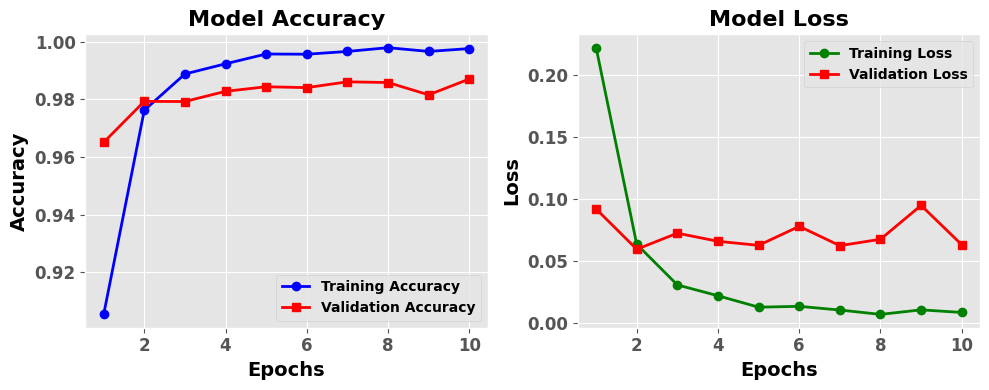

In [19]:
acc = final_history.history['accuracy']
val_acc = final_history.history['val_accuracy']
loss = final_history.history['loss']
val_loss = final_history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(epochs_range, acc, label='Training Accuracy', marker='o', markersize=6, color='blue', linestyle='-', linewidth=2)
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy', marker='s', markersize=6, color='red', linestyle='-', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=16, weight='bold', color='black')
axes[0].set_xlabel('Epochs', fontsize=14, weight='bold', color='black')
axes[0].set_ylabel('Accuracy', fontsize=14, weight='bold', color='black')
axes[0].tick_params(axis='both', labelsize=12)
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontweight('bold')
axes[0].legend(prop={'weight': 'bold', 'size': 10})

axes[1].plot(epochs_range, loss, label='Training Loss', marker='o', markersize=6, color='green', linestyle='-', linewidth=2)
axes[1].plot(epochs_range, val_loss, label='Validation Loss', marker='s', markersize=6, color='red', linestyle='-', linewidth=2)
axes[1].set_title('Model Loss', fontsize=16, weight='bold', color='black')
axes[1].set_xlabel('Epochs', fontsize=14, weight='bold', color='black')
axes[1].set_ylabel('Loss', fontsize=14, weight='bold', color='black')
axes[1].tick_params(axis='both', labelsize=12)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontweight('bold')
axes[1].legend(prop={'weight': 'bold', 'size': 10})

plt.tight_layout()
plt.show()

512/512 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     11110
        Sick       0.98      0.98      0.98      5270

    accuracy                           0.99     16380
   macro avg       0.98      0.99      0.99     16380
weighted avg       0.99      0.99      0.99     16380



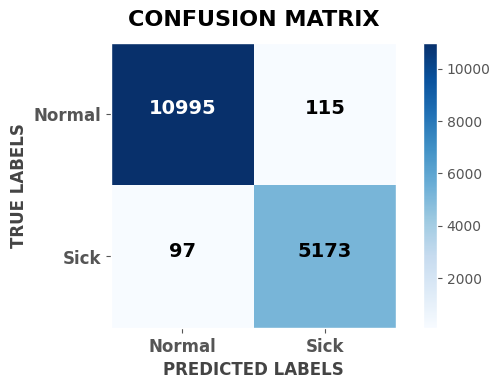

In [58]:
validation_images = []
validation_labels = []
for images, labels in validation:
    validation_images.append(images.numpy())
    validation_labels.append(labels.numpy())
validation_images = np.concatenate(validation_images)
validation_labels = np.concatenate(validation_labels)

predictions = final_model.predict(validation_images)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(validation_labels, predicted_labels)
print("Classification Report:")
print(classification_report(validation_labels, predicted_labels, target_names=class_names))

plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, fontweight='bold', fontsize=12)  
plt.yticks(tick_marks, class_names, fontweight='bold', fontsize=12)  

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontweight='bold', fontsize=14)

plt.grid(False)
plt.title('CONFUSION MATRIX', fontsize=16, fontweight='bold', color='black', y=1.03)
plt.xlabel('PREDICTED LABELS', fontsize=12, fontweight='bold', color='#444444')
plt.ylabel('TRUE LABELS', fontsize=12, fontweight='bold', color='#444444')
plt.tight_layout()
plt.show()

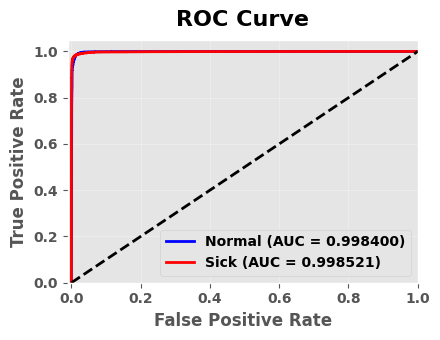

In [59]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_multiclass_roc(y_true, y_score, classes):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve((y_true == i).astype(int), y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    fpr["micro"], tpr["micro"], _ = roc_curve(np.eye(len(classes))[y_true].ravel(), 
                                               y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(4.5,3.5))
    colors = cycle(['blue','red'])
    
    for i, color in zip(range(len(classes)), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='{0} (AUC = {1:f})'.format(classes[i], roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel('False Positive Rate', fontsize=12, fontweight="bold")
    plt.ylabel('True Positive Rate', fontsize=12, fontweight="bold")

    plt.title('ROC Curve', fontsize=16, fontweight="bold", pad=10)

    plt.legend(loc="lower right", fontsize=14, prop={'weight': 'bold'})

    plt.tick_params(axis='both', labelsize=10)
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curves.png', bbox_inches='tight')
    plt.show()

plot_multiclass_roc(validation_labels, predictions, class_names)

In [60]:
import numpy as np
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, cohen_kappa_score)

cm = confusion_matrix(validation_labels, predicted_labels)
tn, fp, fn, tp = cm.ravel()

precision = precision_score(validation_labels, predicted_labels)
recall = recall_score(validation_labels, predicted_labels)

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

f2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) > 0 else 0.0

youden_j = recall + specificity - 1

metrics = {
    'Accuracy': accuracy_score(validation_labels, predicted_labels),
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'Specificity': specificity,
    'F1 Score': f1_score(validation_labels, predicted_labels),
    'F2 Score': f2_score,
    "Cohen's Kappa": cohen_kappa_score(validation_labels, predicted_labels),
    "Youden's J": youden_j  
}

print("\n" + "="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print(f"{'Metric':<30} {'Value':>15}")
print("-"*47)
for name, value in metrics.items():
    print(f"{name:<30} {value:>15.2%}")
print("="*60)


MODEL EVALUATION METRICS
Metric                                   Value
-----------------------------------------------
Accuracy                                98.71%
Precision                               97.83%
Recall (Sensitivity)                    98.16%
Specificity                             98.96%
F1 Score                                97.99%
F2 Score                                98.09%
Cohen's Kappa                           97.04%
Youden's J                              97.12%


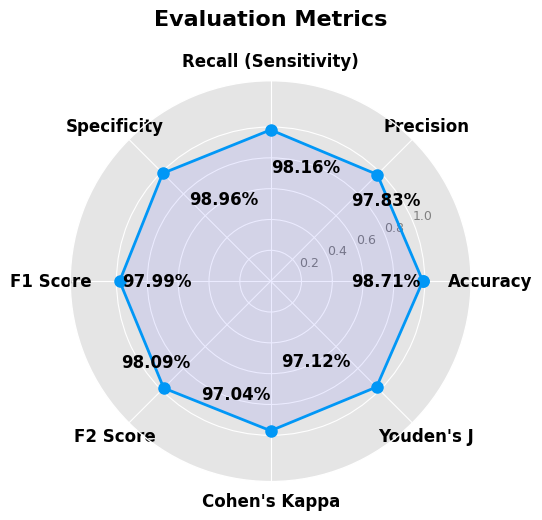

In [62]:
import matplotlib.pyplot as plt
import numpy as np

def plot_radar_metrics(metrics_dict):
    plt.figure(figsize=(5.5,5.5))
    categories = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    values += values[:1]

    ax = plt.subplot(111, polar=True)

    plt.xticks(angles[:-1], categories, color='BLACK', size=12,fontweight='bold')
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=9)
    plt.ylim(0, 1.3)
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#0197f6', marker='o', markersize=8)
    ax.fill(angles, values, color='blue', alpha=0.08)
    
    for i in range(N):
        angle_rad = angles[i]
        value = values[i]
        ha = 'center'
        if angle_rad == 0 or angle_rad == np.pi:
            ha = 'center'
        elif 0 < angle_rad < np.pi:
            ha = 'left'
        else:
            ha = 'right'
        
        ax.text(angle_rad, value -0.24, f'{value:.2%}',
                ha=ha, va='center', fontsize=12, color='black', weight='bold')

    plt.title('Evaluation Metrics', size=16, color='black', fontweight='bold', pad=40)
    
    plt.tight_layout()
    plt.show()

plot_radar_metrics(metrics)

In [40]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

num_classes = 2

base_model = ResNet101(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model3 = tf.keras.Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model3.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=['accuracy']
)
history3 = model2.fit(
    train,
    validation_data=validation,
    epochs=10
)

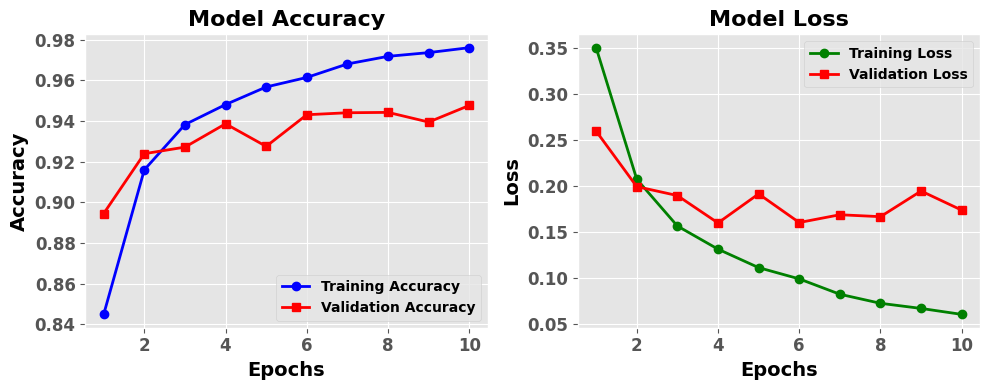

In [40]:
acc = history3.history['accuracy']
val_acc = history3.history['val_accuracy']
loss = history3.history['loss']
val_loss = history3.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(epochs_range, acc, label='Training Accuracy', marker='o', markersize=6, color='blue', linestyle='-', linewidth=2)
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy', marker='s', markersize=6, color='red', linestyle='-', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=16, weight='bold', color='black')
axes[0].set_xlabel('Epochs', fontsize=14, weight='bold', color='black')
axes[0].set_ylabel('Accuracy', fontsize=14, weight='bold', color='black')
axes[0].tick_params(axis='both', labelsize=12)
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontweight('bold')
axes[0].legend(prop={'weight': 'bold', 'size': 10})

axes[1].plot(epochs_range, loss, label='Training Loss', marker='o', markersize=6, color='green', linestyle='-', linewidth=2)
axes[1].plot(epochs_range, val_loss, label='Validation Loss', marker='s', markersize=6, color='red', linestyle='-', linewidth=2)
axes[1].set_title('Model Loss', fontsize=16, weight='bold', color='black')
axes[1].set_xlabel('Epochs', fontsize=14, weight='bold', color='black')
axes[1].set_ylabel('Loss', fontsize=14, weight='bold', color='black')
axes[1].tick_params(axis='both', labelsize=12)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontweight('bold')
axes[1].legend(prop={'weight': 'bold', 'size': 10})

plt.tight_layout()
plt.show()

512/512 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step
Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96     11110
        Sick       0.93      0.91      0.92      5270

    accuracy                           0.95     16380
   macro avg       0.94      0.94      0.94     16380
weighted avg       0.95      0.95      0.95     16380



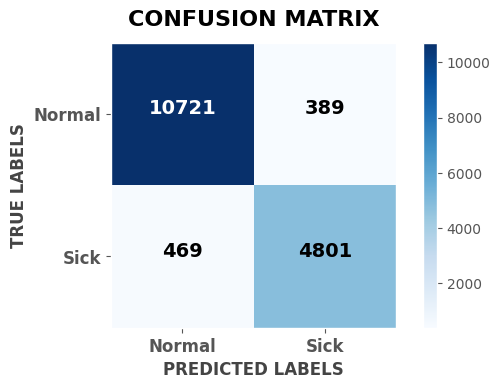

In [63]:
validation_images = []
validation_labels = []
for images, labels in validation:
    validation_images.append(images.numpy())
    validation_labels.append(labels.numpy())
validation_images = np.concatenate(validation_images)
validation_labels = np.concatenate(validation_labels)

predictions = model3.predict(validation_images)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(validation_labels, predicted_labels)
print("Classification Report:")
print(classification_report(validation_labels, predicted_labels, target_names=class_names))

plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, fontweight='bold', fontsize=12)  
plt.yticks(tick_marks, class_names, fontweight='bold', fontsize=12) 

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontweight='bold', fontsize=14)

plt.grid(False)
plt.title('CONFUSION MATRIX', fontsize=16, fontweight='bold', color='black', y=1.03)
plt.xlabel('PREDICTED LABELS', fontsize=12, fontweight='bold', color='#444444')
plt.ylabel('TRUE LABELS', fontsize=12, fontweight='bold', color='#444444')
plt.tight_layout()
plt.show()

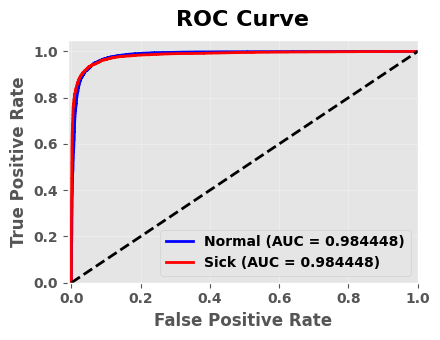

In [64]:
def plot_multiclass_roc(y_true, y_score, classes):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve((y_true == i).astype(int), y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(np.eye(len(classes))[y_true].ravel(), 
                                               y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    plt.figure(figsize=(4.5,3.5))
    colors = cycle(['blue','red'])
    
    for i, color in zip(range(len(classes)), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='{0} (AUC = {1:f})'.format(classes[i], roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    
    plt.xlabel('False Positive Rate', fontsize=12, fontweight="bold")
    plt.ylabel('True Positive Rate', fontsize=12, fontweight="bold")
    
    plt.title('ROC Curve', fontsize=16, fontweight="bold", pad=10)

    plt.legend(loc="lower right", fontsize=14, prop={'weight': 'bold'})

    plt.tick_params(axis='both', labelsize=10)
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curves.png', bbox_inches='tight')
    plt.show()

plot_multiclass_roc(validation_labels, predictions, class_names)

In [65]:
cm = confusion_matrix(validation_labels, predicted_labels)
tn, fp, fn, tp = cm.ravel()

precision = precision_score(validation_labels, predicted_labels)
recall = recall_score(validation_labels, predicted_labels)

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

f2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) > 0 else 0.0

youden_j = recall + specificity - 1

metrics = {
    'Accuracy': accuracy_score(validation_labels, predicted_labels),
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'Specificity': specificity,
    'F1 Score': f1_score(validation_labels, predicted_labels),
    'F2 Score': f2_score,
    "Cohen's Kappa": cohen_kappa_score(validation_labels, predicted_labels),
    "Youden's J": youden_j 
}

print("\n" + "="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print(f"{'Metric':<30} {'Value':>15}")
print("-"*47)
for name, value in metrics.items():
    print(f"{name:<30} {value:>15.2%}")
print("="*60)


MODEL EVALUATION METRICS
Metric                                   Value
-----------------------------------------------
Accuracy                                94.76%
Precision                               92.50%
Recall (Sensitivity)                    91.10%
Specificity                             96.50%
F1 Score                                91.80%
F2 Score                                91.38%
Cohen's Kappa                           87.95%
Youden's J                              87.60%


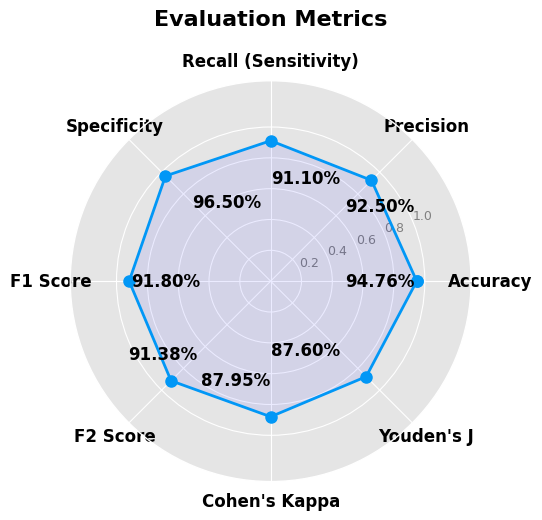

In [66]:
def plot_radar_metrics(metrics_dict):
    plt.figure(figsize=(5.5,5.5))

    categories = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    N = len(categories)

    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  
    values += values[:1]

    ax = plt.subplot(111, polar=True)
    plt.xticks(angles[:-1], categories, color='BLACK', size=12,fontweight='bold')
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=9)
    plt.ylim(0, 1.3)

    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#0197f6', marker='o', markersize=8)
    ax.fill(angles, values, color='blue', alpha=0.08)

    for i in range(N):
        angle_rad = angles[i]
        value = values[i]
        ha = 'center'
        if angle_rad == 0 or angle_rad == np.pi:
            ha = 'center'
        elif 0 < angle_rad < np.pi:
            ha = 'left'
        else:
            ha = 'right'
        
        ax.text(angle_rad, value -0.24, f'{value:.2%}',
                ha=ha, va='center', fontsize=12, color='black', weight='bold')

    plt.title('Evaluation Metrics', size=16, color='black', fontweight='bold', pad=40)
    
    plt.tight_layout()
    plt.show()

plot_radar_metrics(metrics)

In [51]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

num_classes = 2

base_model = DenseNet201(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model4 = tf.keras.Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model4.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=['accuracy']
)
history4 = model3.fit(
    train,
    validation_data=validation,
    epochs=10
)

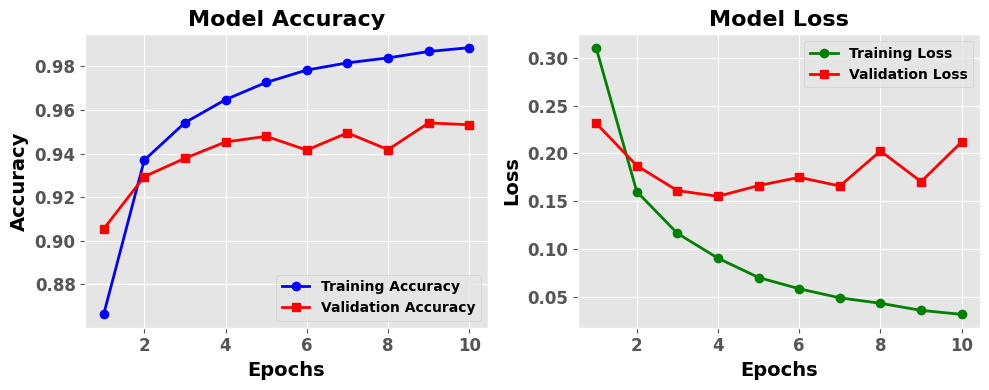

In [68]:
acc = history4.history['accuracy']
val_acc = history4.history['val_accuracy']
loss = history4.history['loss']
val_loss = history4.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(epochs_range, acc, label='Training Accuracy', marker='o', markersize=6, color='blue', linestyle='-', linewidth=2)
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy', marker='s', markersize=6, color='red', linestyle='-', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=16, weight='bold', color='black')
axes[0].set_xlabel('Epochs', fontsize=14, weight='bold', color='black')
axes[0].set_ylabel('Accuracy', fontsize=14, weight='bold', color='black')
axes[0].tick_params(axis='both', labelsize=12)
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontweight('bold')
axes[0].legend(prop={'weight': 'bold', 'size': 10})

axes[1].plot(epochs_range, loss, label='Training Loss', marker='o', markersize=6, color='green', linestyle='-', linewidth=2)
axes[1].plot(epochs_range, val_loss, label='Validation Loss', marker='s', markersize=6, color='red', linestyle='-', linewidth=2)
axes[1].set_title('Model Loss', fontsize=16, weight='bold', color='black')
axes[1].set_xlabel('Epochs', fontsize=14, weight='bold', color='black')
axes[1].set_ylabel('Loss', fontsize=14, weight='bold', color='black')
axes[1].tick_params(axis='both', labelsize=12)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontweight('bold')
axes[1].legend(prop={'weight': 'bold', 'size': 10})

plt.tight_layout()
plt.show()

512/512 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/step
Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97     11110
        Sick       0.95      0.91      0.93      5270

    accuracy                           0.95     16380
   macro avg       0.95      0.94      0.95     16380
weighted avg       0.95      0.95      0.95     16380



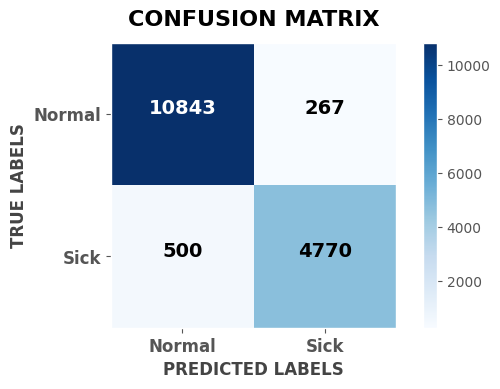

In [69]:
validation_images = []
validation_labels = []
for images, labels in validation:
    validation_images.append(images.numpy())
    validation_labels.append(labels.numpy())
validation_images = np.concatenate(validation_images)
validation_labels = np.concatenate(validation_labels)

predictions =model4.predict(validation_images)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(validation_labels, predicted_labels)
print("Classification Report:")
print(classification_report(validation_labels, predicted_labels, target_names=class_names))

plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, fontweight='bold', fontsize=12)  
plt.yticks(tick_marks, class_names, fontweight='bold', fontsize=12)  

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontweight='bold', fontsize=14)  

plt.grid(False)
plt.title('CONFUSION MATRIX', fontsize=16, fontweight='bold', color='black', y=1.03)
plt.xlabel('PREDICTED LABELS', fontsize=12, fontweight='bold', color='#444444')
plt.ylabel('TRUE LABELS', fontsize=12, fontweight='bold', color='#444444')
plt.tight_layout()
plt.show()


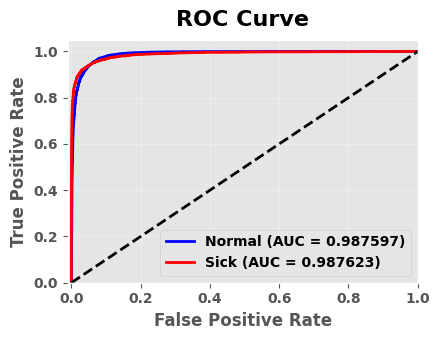

In [70]:
def plot_multiclass_roc(y_true, y_score, classes):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve((y_true == i).astype(int), y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(np.eye(len(classes))[y_true].ravel(), 
                                               y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    plt.figure(figsize=(4.5,3.5))
    colors = cycle(['blue','red'])
    
    for i, color in zip(range(len(classes)), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='{0} (AUC = {1:f})'.format(classes[i], roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    
    plt.xlabel('False Positive Rate', fontsize=12, fontweight="bold")
    plt.ylabel('True Positive Rate', fontsize=12, fontweight="bold")
    
    plt.title('ROC Curve', fontsize=16, fontweight="bold", pad=10)
    plt.legend(loc="lower right", fontsize=14, prop={'weight': 'bold'})

    plt.tick_params(axis='both', labelsize=10)
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curves.png', bbox_inches='tight')
    plt.show()

plot_multiclass_roc(validation_labels, predictions, class_names)


In [71]:
cm = confusion_matrix(validation_labels, predicted_labels)
tn, fp, fn, tp = cm.ravel()

precision = precision_score(validation_labels, predicted_labels)
recall = recall_score(validation_labels, predicted_labels)

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

f2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) > 0 else 0.0

youden_j = recall + specificity - 1

metrics = {
    'Accuracy': accuracy_score(validation_labels, predicted_labels),
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'Specificity': specificity,
    'F1 Score': f1_score(validation_labels, predicted_labels),
    'F2 Score': f2_score,
    "Cohen's Kappa": cohen_kappa_score(validation_labels, predicted_labels),
    "Youden's J": youden_j  
}

print("\n" + "="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print(f"{'Metric':<30} {'Value':>15}")
print("-"*47)
for name, value in metrics.items():
    print(f"{name:<30} {value:>15.2%}")
print("="*60)


MODEL EVALUATION METRICS
Metric                                   Value
-----------------------------------------------
Accuracy                                95.32%
Precision                               94.70%
Recall (Sensitivity)                    90.51%
Specificity                             97.60%
F1 Score                                92.56%
F2 Score                                91.32%
Cohen's Kappa                           89.14%
Youden's J                              88.11%


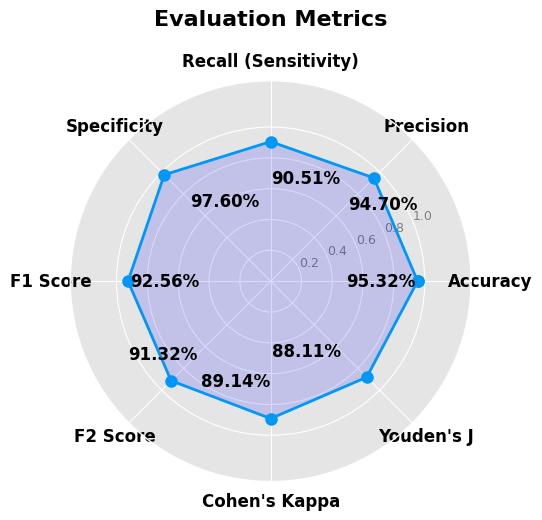

In [72]:
def plot_radar_metrics(metrics_dict):
    plt.figure(figsize=(5.5,5.5))

    categories = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    N = len(categories)
    
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  
    values += values[:1]
    
    ax = plt.subplot(111, polar=True)

    plt.xticks(angles[:-1], categories, color='BLACK', size=12,fontweight='bold')
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=9)
    plt.ylim(0, 1.3)
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#0197f6', marker='o', markersize=8)
    ax.fill(angles, values, color='blue', alpha=0.15)
    
    for i in range(N):
        angle_rad = angles[i]
        value = values[i]
        ha = 'center'
        if angle_rad == 0 or angle_rad == np.pi:
            ha = 'center'
        elif 0 < angle_rad < np.pi:
            ha = 'left'
        else:
            ha = 'right'
        
        ax.text(angle_rad, value -0.24, f'{value:.2%}',
                ha=ha, va='center', fontsize=12, color='black', weight='bold')
    
    plt.title('Evaluation Metrics', size=16, color='black', fontweight='bold', pad=40)
    
    plt.tight_layout()
    plt.show()


plot_radar_metrics(metrics)

In [27]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import EfficientNetV2B0

pretrained_model = EfficientNetV2B0(
    include_top=False,
    input_shape=(224,224,3),
    pooling='avg',
    weights='imagenet'
)

for layer in pretrained_model.layers:
    layer.trainable = False

model5 = Sequential()
model5.add(
    layers.Rescaling(
        1./255,
        input_shape=(224,224, 3)
    )
)

model5.add(pretrained_model)

model5.add(layers.Flatten())

model5.add(
    layers.Dense(
        256,
        activation='relu'
    )
)

model5.add(
    layers.Dense(
        128,
        activation='relu'
    )
)

model5.add(
    layers.Dense(
        64,
        activation='relu'
    )
)

model5.add(
    layers.Dense(
        2,
        activation='softmax'
    )
)


model5.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=['accuracy']
)
history5 = model5.fit(
    train,
    validation_data=validation,
    epochs=10
)

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


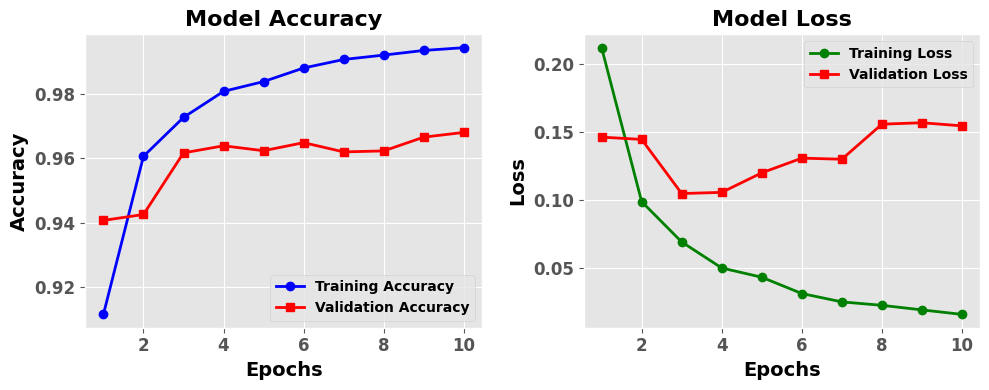

In [87]:
import matplotlib.pyplot as plt

acc = history5.history['accuracy']
val_acc = history5.history['val_accuracy']
loss = history5.history['loss']
val_loss = history5.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(epochs_range, acc, label='Training Accuracy', marker='o', markersize=6, color='blue', linestyle='-', linewidth=2)
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy', marker='s', markersize=6, color='red', linestyle='-', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=16, weight='bold', color='black')
axes[0].set_xlabel('Epochs', fontsize=14, weight='bold', color='black')
axes[0].set_ylabel('Accuracy', fontsize=14, weight='bold', color='black')
axes[0].tick_params(axis='both', labelsize=12)
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontweight('bold')
axes[0].legend(prop={'weight': 'bold', 'size': 10})

axes[1].plot(epochs_range, loss, label='Training Loss', marker='o', markersize=6, color='green', linestyle='-', linewidth=2)
axes[1].plot(epochs_range, val_loss, label='Validation Loss', marker='s', markersize=6, color='red', linestyle='-', linewidth=2)
axes[1].set_title('Model Loss', fontsize=16, weight='bold', color='black')
axes[1].set_xlabel('Epochs', fontsize=14, weight='bold', color='black')
axes[1].set_ylabel('Loss', fontsize=14, weight='bold', color='black')
axes[1].tick_params(axis='both', labelsize=12)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontweight('bold')
axes[1].legend(prop={'weight': 'bold', 'size': 10})

plt.tight_layout()
plt.show()

512/512 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step
Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98     11110
        Sick       0.97      0.93      0.95      5270

    accuracy                           0.97     16380
   macro avg       0.97      0.96      0.96     16380
weighted avg       0.97      0.97      0.97     16380



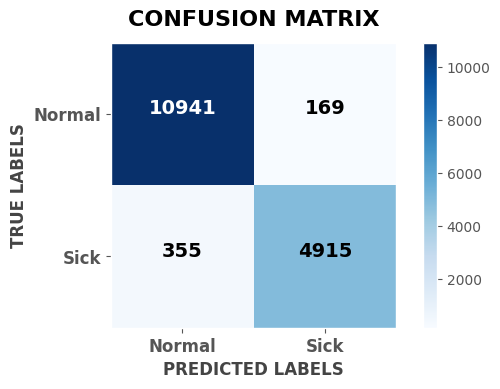

In [80]:
validation_images = []
validation_labels = []
for images, labels in validation:
    validation_images.append(images.numpy())
    validation_labels.append(labels.numpy())
validation_images = np.concatenate(validation_images)
validation_labels = np.concatenate(validation_labels)

predictions =model5.predict(validation_images)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(validation_labels, predicted_labels)
print("Classification Report:")
print(classification_report(validation_labels, predicted_labels, target_names=class_names))

plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, fontweight='bold', fontsize=12)  
plt.yticks(tick_marks, class_names, fontweight='bold', fontsize=12)  

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontweight='bold', fontsize=14)  

plt.grid(False)
plt.title('CONFUSION MATRIX', fontsize=16, fontweight='bold', color='black', y=1.03)
plt.xlabel('PREDICTED LABELS', fontsize=12, fontweight='bold', color='#444444')
plt.ylabel('TRUE LABELS', fontsize=12, fontweight='bold', color='#444444')
plt.tight_layout()
plt.show()

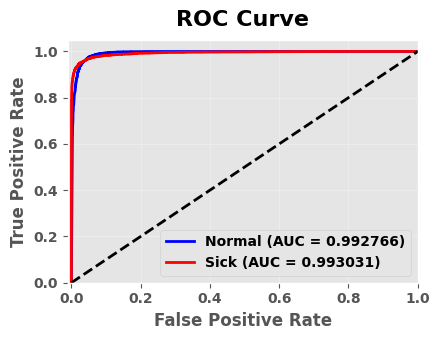

In [81]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_multiclass_roc(y_true, y_score, classes):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve((y_true == i).astype(int), y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    fpr["micro"], tpr["micro"], _ = roc_curve(np.eye(len(classes))[y_true].ravel(), 
                                               y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    plt.figure(figsize=(4.5,3.5))
    colors = cycle(['blue','red'])
    
    for i, color in zip(range(len(classes)), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='{0} (AUC = {1:f})'.format(classes[i], roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    
    plt.xlabel('False Positive Rate', fontsize=12, fontweight="bold")
    plt.ylabel('True Positive Rate', fontsize=12, fontweight="bold")
    
    plt.title('ROC Curve', fontsize=16, fontweight="bold", pad=10)
    plt.legend(loc="lower right", fontsize=14, prop={'weight': 'bold'})

    plt.tick_params(axis='both', labelsize=10)
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curves.png', bbox_inches='tight')
    plt.show()

plot_multiclass_roc(validation_labels, predictions, class_names)

In [82]:
import numpy as np
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, cohen_kappa_score)

cm = confusion_matrix(validation_labels, predicted_labels)
tn, fp, fn, tp = cm.ravel()

precision = precision_score(validation_labels, predicted_labels)
recall = recall_score(validation_labels, predicted_labels)

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
f2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) > 0 else 0.0

youden_j = recall + specificity - 1

metrics = {
    'Accuracy': accuracy_score(validation_labels, predicted_labels),
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'Specificity': specificity,
    'F1 Score': f1_score(validation_labels, predicted_labels),
    'F2 Score': f2_score,
    "Cohen's Kappa": cohen_kappa_score(validation_labels, predicted_labels),
    "Youden's J": youden_j  # Updated short label
}

print("\n" + "="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print(f"{'Metric':<30} {'Value':>15}")
print("-"*47)
for name, value in metrics.items():
    print(f"{name:<30} {value:>15.2%}")
print("="*60)



MODEL EVALUATION METRICS
Metric                                   Value
-----------------------------------------------
Accuracy                                96.80%
Precision                               96.68%
Recall (Sensitivity)                    93.26%
Specificity                             98.48%
F1 Score                                94.94%
F2 Score                                93.93%
Cohen's Kappa                           92.60%
Youden's J                              91.74%


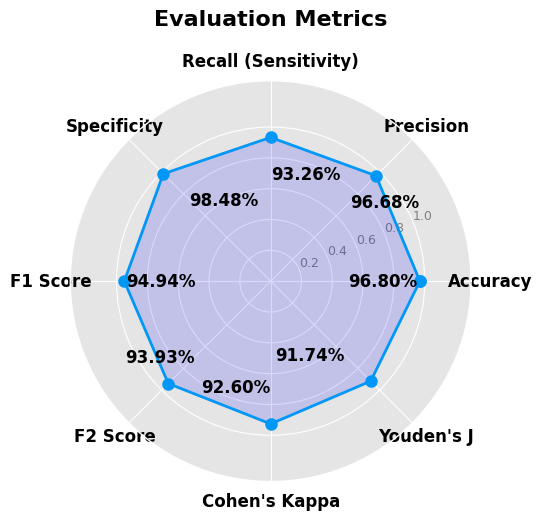

In [83]:
def plot_radar_metrics(metrics_dict):
    plt.figure(figsize=(5.5,5.5))

    categories = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    N = len(categories)

    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    values += values[:1]

    ax = plt.subplot(111, polar=True)
    
    plt.xticks(angles[:-1], categories, color='BLACK', size=12,fontweight='bold')
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=9)
    plt.ylim(0, 1.3)
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#0197f6', marker='o', markersize=8)
    ax.fill(angles, values, color='blue', alpha=0.15)
    
    for i in range(N):
        angle_rad = angles[i]
        value = values[i]
        ha = 'center'
        if angle_rad == 0 or angle_rad == np.pi:
            ha = 'center'
        elif 0 < angle_rad < np.pi:
            ha = 'left'
        else:
            ha = 'right'
        
        ax.text(angle_rad, value -0.24, f'{value:.2%}',
                ha=ha, va='center', fontsize=12, color='black', weight='bold')

    plt.title('Evaluation Metrics', size=16, color='black', fontweight='bold', pad=40)
    
    plt.tight_layout()
    plt.show()
plot_radar_metrics(metrics)